In [ ]:
# Execute first
import os
FIG_ROOT = os.environ.get('SCDIS_FIG', os.path.join(os.environ['SCDIS_ROOT'], 'figures'))

In [1]:
import scanpy as sc
import anndata as ad
import numpy as np
import pandas as pd
import scipy
import matplotlib.pyplot as plt
import os
from tqdm import tqdm
from typing import Sequence, Optional

In [2]:
import matplotlib
matplotlib.rcParams['svg.fonttype'] = 'none'
matplotlib.rcParams['font.family'] = 'Liberation Sans'
matplotlib.rcParams['mathtext.default'] = 'regular'
matplotlib.rcParams['axes.unicode_minus'] = False

In [3]:
def plot_dotplot_scanpy(
    adata_list,
    labels,
    gene_names,
    expression_cutoff,
    cmap,
    standard_scale,
    save_path = None,
    **dotplot_kwargs,
):
    """
    Params
    ----------
        adata_list: list of adatas
        labels: list of their corresponding labels 
        gene_names: genes to plot
        expression_cutoff
            Min to count as expressing
        standard_scale
        save_path: str or None
        show: Bool
        **dotplot_kwargs: forwared to sc.pl.dotplot
    """
    
    tagged = []
    for a, lbl in zip(adata_list, labels):
        a_cp = a.copy()
        a_cp.obs["dotplot_grp"] = lbl
        tagged.append(a_cp)
    adata_combined = ad.concat(tagged)
   
    adata_combined.obs["dotplot_grp"] = pd.Categorical(
        adata_combined.obs["dotplot_grp"],
        categories=list(labels),     
        ordered=True
    )
    dp = sc.pl.dotplot(
        adata_combined,
        var_names=gene_names,
        groupby="dotplot_grp",
        expression_cutoff=expression_cutoff,
        standard_scale=standard_scale,
        color_map=cmap,
        return_fig=True,
        show=False,               
        **dotplot_kwargs,
    )
    
    # save
    if save_path:
        dp.savefig(f"{save_path}.png", dpi=500, bbox_inches="tight")
        dp.savefig(f"{save_path}.svg", dpi=500, bbox_inches="tight")

    return dp

In [4]:
save_dir = f'{FIG_ROOT}/liver_hpi/'
if not os.path.exists(save_dir):
    os.makedirs(save_dir)

In [5]:
adata_observed = sc.read_h5ad('../../Datasets/preprocessed_datasets/liver.h5ad')
adata_predicted = None
for a_file in tqdm(['pred_ctrl_Pericentral.h5ad', 'pred_ctrl_Periportal.h5ad', 'pred_infected_Pericentral.h5ad',
              'pred_infected_Periportal.h5ad', 'pred_uninfected_Pericentral.h5ad', 
              'pred_uninfected_Periportal.h5ad']):
    _adata_pred = sc.read_h5ad(a_file)
    if adata_predicted is None:
        adata_predicted = _adata_pred.copy()
    else:
        adata_predicted = ad.concat([adata_predicted, _adata_pred])

  0%|                                                                                                                                                                                        | 0/6 [00:00<?, ?it/s]/home/SE/miniconda3/envs/trials/lib/python3.10/site-packages/anndata/_core/anndata.py:1818: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/SE/miniconda3/envs/trials/lib/python3.10/site-packages/anndata/_core/anndata.py:1818: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/SE/miniconda3/envs/trials/lib/python3.10/site-packages/anndata/_core/anndata.py:1818: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
 50%|████████████████████████████████████████████████████████████████████████████████████████            

# Normalize

In [6]:
sc.pp.normalize_total(adata_observed)
sc.pp.normalize_total(adata_predicted)
sc.pp.log1p(adata_observed)
sc.pp.log1p(adata_predicted)

adata.X seems to be already log-transformed.


# Concat

In [7]:
adata_observed.obs['y'] = 'Observed'
adata_predicted.obs['y'] = 'Predicted'
adata_cat = ad.concat([adata_observed, adata_predicted])

/home/SE/miniconda3/envs/trials/lib/python3.10/site-packages/anndata/_core/merge.py:1362: UserWarning: Only some AnnData objects have `.raw` attribute, not concatenating `.raw` attributes.
  warn(
/home/SE/miniconda3/envs/trials/lib/python3.10/site-packages/anndata/_core/anndata.py:1818: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


# Dot Plot

In [8]:
import sys
sys.path.append('../../Datasets/preprocessing_scripts')

In [9]:
import preprocessing_tools as pt

rank_genes_groups_hpi_specific = {}

for condition in tqdm(['Infected_2 hpi', 'Infected_12 hpi', 'Infected_24 hpi', 'Infected_30 hpi', 'Infected_36 hpi']):

    hpi_specific_degs = pt.compute_degs(
            adata_observed, 
            cov_key='zone',
            cond_key='coarse_status', 
            stim_name=condition, 
            control_name='',
            condition_names=['Infected_2 hpi', 'Infected_12 hpi', 'Infected_24 hpi', 'Infected_30 hpi', 'Infected_36 hpi'],
            synergy=True,
            rankby_abs=False,
            method='wilcoxon'
        )
    rank_genes_groups_hpi_specific[condition] = hpi_specific_degs

  0%|                                                                                                                                                                                        | 0/5 [00:00<?, ?it/s]/home/SE/miniconda3/envs/trials/lib/python3.10/site-packages/numba/np/ufunc/parallel.py:371: NumbaWarning: The TBB threading layer requires TBB version 2021 update 6 or later i.e., TBB_INTERFACE_VERSION >= 12060. Found TBB_INTERFACE_VERSION = 12050. The TBB threading layer is disabled.
  warnings.warn(problem)
100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5/5 [00:15<00:00,  3.01s/it]


['Steap4', 'Mt2', 'Cxcl10', 'Mt1', 'Saa2', 'Serpina3n', 'Lcn2', 'Calr', 'Podn', 'Ftl1-ps1', 'Gsta3', 'Iigp1', 'Apoa1', 'Hpx', 'Rnase4', 'Clu', 'Ifit1', 'Rsad2', 'Ifit3', 'Isg15']


/home/SE/miniconda3/envs/trials/lib/python3.10/site-packages/anndata/_core/anndata.py:1818: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/SE/miniconda3/envs/trials/lib/python3.10/site-packages/anndata/_core/merge.py:1362: UserWarning: Only some AnnData objects have `.raw` attribute, not concatenating `.raw` attributes.
  warn(
/home/SE/miniconda3/envs/trials/lib/python3.10/site-packages/anndata/_core/anndata.py:1818: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


['Mt2', 'Steap4', 'Mt1', 'Cxcl10', 'Serpina3n', 'Lcn2', 'Saa1', 'Saa2', 'Podn', 'Serpina1e', 'Ftl1-ps1', 'Cps1', 'Apoa1', 'Rnase4', 'Hpx', 'B2m', 'Rsad2', 'Ifit1', 'Ifit3', 'Isg15']


/home/SE/miniconda3/envs/trials/lib/python3.10/site-packages/anndata/_core/merge.py:1362: UserWarning: Only some AnnData objects have `.raw` attribute, not concatenating `.raw` attributes.
  warn(
/home/SE/miniconda3/envs/trials/lib/python3.10/site-packages/anndata/_core/anndata.py:1818: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


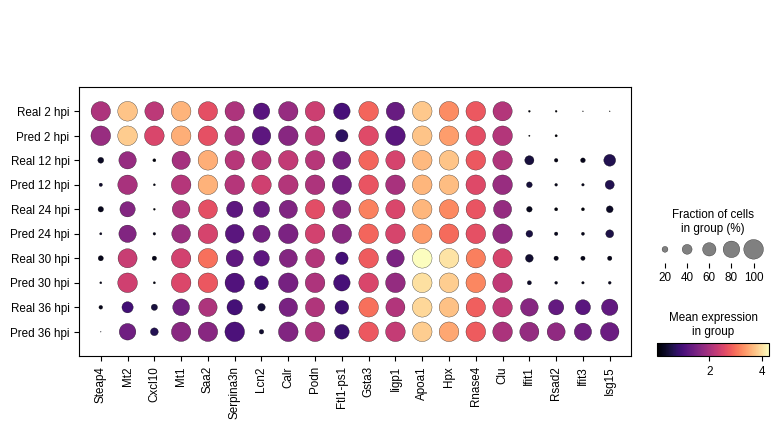

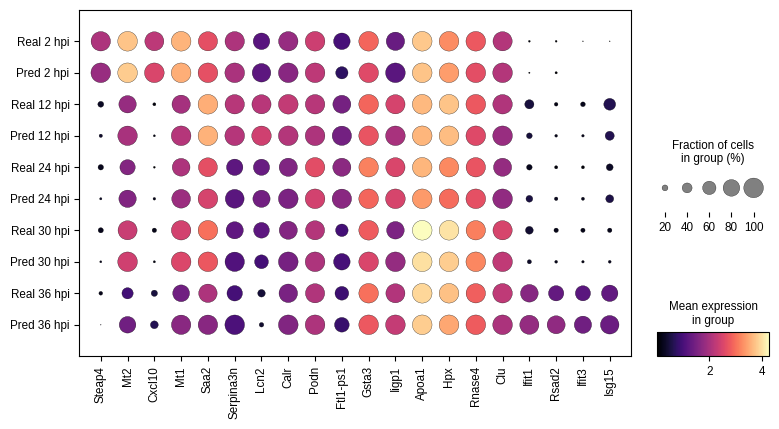

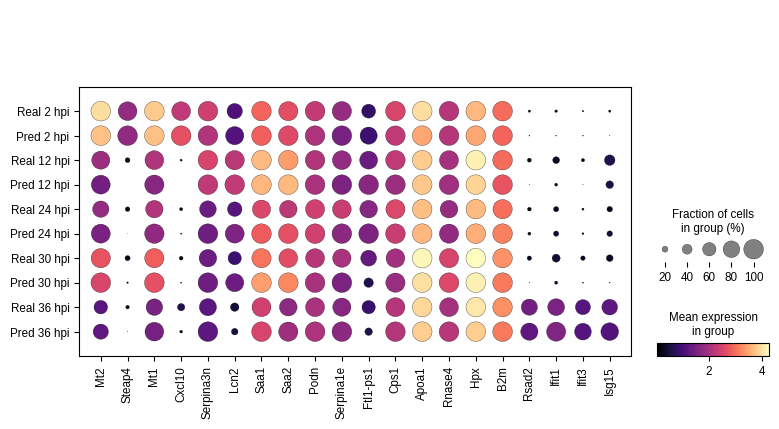

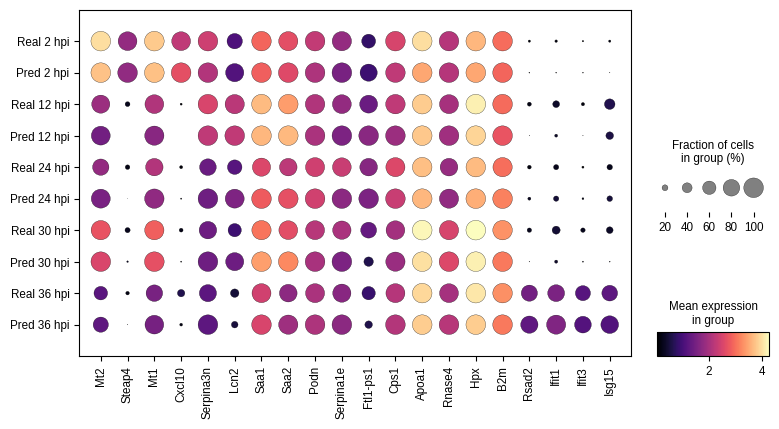

In [10]:
for ood_cov in ['Pericentral', 'Periportal']:

    # Time-specific DEGs
    degs_list_specific = []
    for tp in ['2 hpi', '12 hpi', '24 hpi', '30 hpi', '36 hpi']:
        degs_specific = rank_genes_groups_hpi_specific['Infected_'+tp][ood_cov]
        added=0
        for de_sp in degs_specific.tolist():
            if not de_sp in degs_list_specific:
                degs_list_specific.append(de_sp)
                added+=1
            if added == 4:
                break
    degs_list_specific = list(dict.fromkeys(degs_list_specific))
    print(degs_list_specific)

    # Make list of dataset and labels (to prepare for dotplot input)
    adata_cat_list = []
    labels = []
    hpi_times = ['2 hpi', '12 hpi', '24 hpi', '30 hpi', '36 hpi']
    for i in range(5):
        adata_observed_subset = adata_observed[(adata_observed.obs['zone'] == ood_cov) & \
                                (adata_observed.obs['coarse_time'] == hpi_times[i]) & \
                                (adata_observed.obs['status_control'] == 'Infected')]
    
        adata_predicted_subset = adata_predicted[(adata_predicted.obs['zone'] == ood_cov) & \
                                (adata_predicted.obs['coarse_time'] == hpi_times[i]) & \
                                (adata_predicted.obs['status_control'] == 'Infected')]
        
        adata_cat_list.append(adata_observed_subset)
        adata_cat_list.append(adata_predicted_subset)
        labels.append(f'Real {hpi_times[i]}')
        labels.append(f'Pred {hpi_times[i]}')

    # Dotplot
    plot_dotplot_scanpy(
        adata_cat_list, 
        labels, 
        degs_list_specific, 
        cmap='magma', 
        expression_cutoff = 0.7, 
        standard_scale=None, 
        save_path=save_dir+ood_cov+'_dot'
    )